# Задание 2. Нейронный оператор Фурье.
### Новикова Вера, вариант 6.

In [20]:
!pip install pytorch_lightning

In [1]:
!pip install neuraloperator

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 35.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.9/186.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 21.7 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 97.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.2/722.2 kB 35.9 MB/s eta 0:00:00
  Created wheel for torch-harmonics: filename=torch_harmonics-0.7.3-py3-none-any.whl size=87748 sha256=50dccdd4510fe054549095e3440bdc2e147e6e4c60628e5ebd7ec217

In [2]:
import os
import numpy as np

import torch
import matplotlib.pyplot as plt

import neuralop

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda'

In [22]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from neuralop.models import FNO2d
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pytorch_lightning as pl

**Software:**

In [4]:
print("neuralop v" + neuralop.__version__)
print("pytorch v" + torch.__version__)
print("numpy v" + np.__version__)

neuralop v1.0.2
pytorch v2.5.1+cu121
numpy v1.26.4


![title](./imgs/burgers.png)

**Data overview**

In [5]:
from scipy.io import loadmat

In [6]:
data = loadmat("../input/burgers-xt/burgers_xt/burgers_v100_t100_r1024_N2048.mat")

/usr/local/lib/python3.10/dist-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [7]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'input', 'output', 'sigma', 'steps', 'tau', 'tspan', 'None', 'u0eval', 'visc', '__function_workspace__'])

In [8]:
x_data = torch.from_numpy(data['input'])
y_data = torch.from_numpy(data['output'])

In [9]:
x_data.shape, y_data.shape

(torch.Size([2048, 1024]), torch.Size([2048, 101, 1024]))

In [10]:
print("Набор начальных приближений (x_data.mat) формы (B, X): ", x_data.shape)
print("Набор соответствующих решений ур-я Бюргерса (y_data.mat) формы (B, T, X): ", y_data.shape)

Набор начальных приближений (x_data.mat) формы (B, X):  torch.Size([2048, 1024])
Набор соответствующих решений ур-я Бюргерса (y_data.mat) формы (B, T, X):  torch.Size([2048, 101, 1024])


In [11]:
idx = 13  # Visualize a single sample.

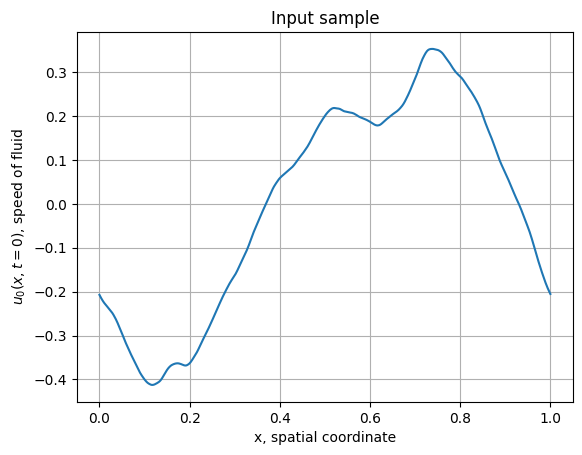

In [12]:
fig, ax = plt.subplots()
x = np.linspace(0, 1, 1024)

ax.plot(x, x_data[idx])
ax.set(xlabel='x, spatial coordinate',
       ylabel=r"$u_{0}(x, t=0)$, speed of fluid",
       title='Input sample')
ax.grid()

plt.show()

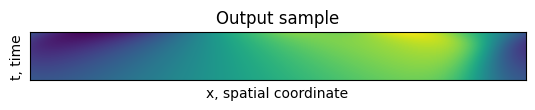

In [13]:
fig, ax = plt.subplots()

ax.imshow(y_data[idx])
ax.set(xticks=[], yticks=[], ylabel="t, time", xlabel="x, spatial coordinate",
       title='Output sample')

plt.show()

# Задание 1

In [14]:
STEP = 10
BATCH_SIZE = 8
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = x_data.unsqueeze(1).unsqueeze(1).repeat(1, 1, 101, 1).float()
Y = y_data.float()

num_samples = X.size(0)
train_size = int(0.8 * num_samples)
indices = torch.randperm(num_samples)

train_idx, val_idx = indices[:train_size], indices[train_size:]
x_train, y_train = X[train_idx], Y[train_idx]
x_val, y_val = X[val_idx], Y[val_idx]

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=BATCH_SIZE)

param_grid = {
    'num_layers': [2, 4, 6],
    'n_modes_height': [8, 12],
    'n_modes_width': [8, 12],
    'hidden_channels': [32, 64],
}

best_val_loss = float('inf')
best_train_losses, best_val_losses = [], []
best_params = None

for params in ParameterGrid(param_grid):
    print(f"Testing parameters: {params}")
    
    model = FNO2d(
        in_channels=1,
        out_channels=1,
        n_modes_height=params['n_modes_height'],
        n_modes_width=params['n_modes_width'],
        hidden_channels=params['hidden_channels'],
        n_layers=params['num_layers']
    ).to(DEVICE)
    
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_train_loss = 0.0

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"):
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            predictions = model(X_batch).squeeze(1).float()
            loss = loss_fn(predictions, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        epoch_train_loss /= len(train_loader)
        train_losses.append(epoch_train_loss)

        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                predictions = model(X_batch).squeeze(1).float()
                loss = loss_fn(predictions, y_batch)
                epoch_val_loss += loss.item()

        epoch_val_loss /= len(val_loader)
        val_losses.append(epoch_val_loss)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch + 1:>2}/{NUM_EPOCHS} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_train_losses = train_losses
        best_val_losses = val_losses
        best_params = params

    print("\n" + "-" * 75 + "\n")

Testing parameters: {'hidden_channels': 32, 'n_modes_height': 8, 'n_modes_width': 8, 'num_layers': 2}


Epoch 1/5: 100%|██████████| 205/205 [00:38<00:00,  5.35it/s]


Epoch  1/5 | Train Loss: 0.009085 | Val Loss: 0.001063


Epoch 2/5: 100%|██████████| 205/205 [00:38<00:00,  5.34it/s]


Epoch  2/5 | Train Loss: 0.000665 | Val Loss: 0.000527


...

Epoch  3/5 | Train Loss: 0.000024 | Val Loss: 0.000017


Epoch 4/5: 100%|██████████| 205/205 [03:31<00:00,  1.03s/it]


Epoch  4/5 | Train Loss: 0.000020 | Val Loss: 0.000029


Epoch 5/5: 100%|██████████| 205/205 [03:31<00:00,  1.03s/it]


Epoch  5/5 | Train Loss: 0.000017 | Val Loss: 0.000032

---------------------------------------------------------------------------



Best parameters: {'hidden_channels': 32, 'n_modes_height': 12, 'n_modes_width': 12, 'num_layers': 6}
Best validation Loss: 0.000013


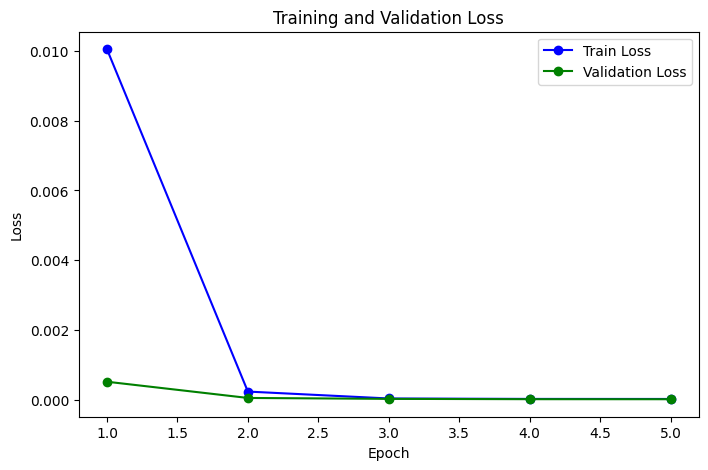

In [15]:
print(f"Best parameters: {best_params}")
print(f"Best validation Loss: {best_val_loss:.6f}")

epochs = range(1, len(best_train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, best_train_losses, label="Train Loss", marker="o", color="b")
plt.plot(epochs, best_val_losses, label="Validation Loss", marker="o", color="g")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Выводы:
Количество Фурье-блоков значительно влияет на качество модели. В целом она обучается быстро, при увеличении количества Фурье-блоков и скрытых слоев время обучения ожидаемо увеличивается.

# Задание 2

In [17]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        """
        Performs complex multiplication in Fourier space.
        """
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        
        x_ft = torch.fft.rfft2(x)
        
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        
        x_out = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x_out

In [28]:
class FNO2dMine(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2, width, num_layers):
        super(FNO2dMine, self).__init__()
        
        self.width = width
        self.modes1 = modes1
        self.modes2 = modes2
        self.num_layers = num_layers
        
        self.fc0 = nn.Linear(in_channels, self.width)  
        
        self.spectral_layers = nn.ModuleList([
            SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
            for _ in range(self.num_layers)
        ])
        
        self.conv_layers = nn.ModuleList([
            nn.Conv2d(self.width, self.width, 1)
            for _ in range(self.num_layers)
        ])
        
        self.fc1 = nn.Linear(self.width, 64)
        self.fc2 = nn.Linear(64, out_channels)
        
        self.activation = nn.ReLU()

    def fourier_layer(self, x, spectral_layer, conv_layer):
        return self.activation(spectral_layer(x) + conv_layer(x))
    
    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)  
        
        for i in range(self.num_layers):
            x = self.fourier_layer(x, self.spectral_layers[i], self.conv_layers[i])
        
        x = x.permute(0, 2, 3, 1)  
        
        x = self.activation(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)

In [23]:
class FNO2dLightning(pl.LightningModule):
    def __init__(self, network, lr=1e-3):
        super(FNO2dLightning, self).__init__()
        self.network = network
        self.lr = lr
        self.loss_fn = nn.MSELoss()
    
    def configure_optimizers(self):
        return optim.Adam(self.network.parameters(), lr=self.lr)
    
    def forward(self, x):
        x = self.network(x)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.loss_fn(y_pred, y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [32]:
MODES1 = 12
MODES2 = 12
WIDTH = 32
num_layers_range = [i for i in range(1, 11)]
val_losses = []

for n in num_layers_range:
    network = FNO2dMine(
        in_channels=1,
        out_channels=1,
        modes1=MODES1,
        modes2=MODES2,
        width=WIDTH,
        num_layers=n
    )
    lightning_model = FNO2dLightning(network)
    trainer = pl.Trainer(max_epochs=5, accelerator='gpu')
    trainer.fit(lightning_model, train_loader, val_loader)
    val_loss = trainer.callaback_metrics["val_loss"].item()
    val_losses.append(val_loss)

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

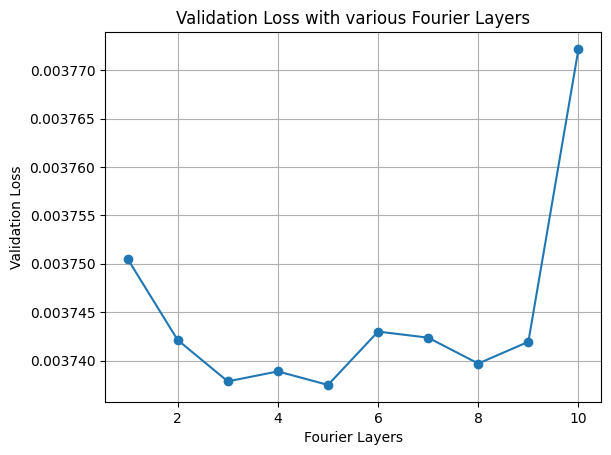

In [33]:
plt.plot(num_layers_range, val_losses, marker="o", linestyle="-")
plt.xlabel("Fourier Layers")
plt.ylabel("Validation Loss")
plt.title("Validation Loss with various Fourier Layers")
plt.grid()
plt.show()

# Выводы:
Из графика потерь на валидационной выборке видно, что оптимальное количество Фурье-блоков равняется 3-5. Увеличение числа блоков выше этого количества приводит к ухудшению модели. Впрочем, разница между значениями лосса всего в 5 знаке после запятой.